### IMPORTS DE LIBRERIAS Y CARGA DE DATOS ###

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/server_logs.csv')

### PASOS PREVIOS ###

In [3]:
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

print("---------------------------------------")
print("Tipo:", df['timestamp_event'].dtype)
print("Desde:", df['timestamp_event'].min())
print("Hasta:", df['timestamp_event'].max())

df['is_bad'] = ((df['severity'].isin(['ERROR', 'CRITICAL'])) |(df['status_code'] >= 500))

print("---------------------------------------")
print("Total eventos:", len(df))
print("Bad events:", df['is_bad'].sum())
print("Bad rate global:", round(df['is_bad'].mean() * 100, 2), "%")
print("Total de logs:", len(df))
print("---------------------------------------")
print(df['severity'].value_counts())
print("---------------------------------------")


---------------------------------------
Tipo: datetime64[us, UTC]
Desde: 2026-01-10 00:02:39.029160+00:00
Hasta: 2026-01-12 23:59:23.187914+00:00
---------------------------------------
Total eventos: 5795
Bad events: 895
Bad rate global: 15.44 %
Total de logs: 5795
---------------------------------------
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64
---------------------------------------


In [18]:
conteo_servicios = df['service_name'].value_counts()
print("Servicio con MÁS logs:")
print(conteo_servicios.head(1))
print()
print("Servicio con MENOS logs:")
print(conteo_servicios.tail(1))

Servicio con MÁS logs:
service_name
api-gateway    1509
Name: count, dtype: int64

Servicio con MENOS logs:
service_name
notification-service    645
Name: count, dtype: int64


In [30]:
print("Mensaje más repetido:")
print(df['message'].value_counts().head(1))

Mensaje más repetido:
message
Health check OK    1196
Name: count, dtype: int64


In [31]:
print("Mensaje malo más repetido:")
print(df[df['is_bad'] == True]['message'].value_counts().head(1))

Mensaje malo más repetido:
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


In [32]:
df['window'] = df['timestamp_event'].dt.floor('5min')
print("Bins creados. Ejemplo:")
print(df['window'].head(3))

Bins creados. Ejemplo:
0   2026-01-10 00:00:00+00:00
1   2026-01-10 00:00:00+00:00
2   2026-01-10 00:00:00+00:00
Name: window, dtype: datetime64[us, UTC]


In [33]:
resumen = df.groupby('window').agg(
    total_events=('is_bad', 'count'),
    bad_events=('is_bad', 'sum')
).reset_index()

resumen['bad_rate'] = resumen['bad_events'] / resumen['total_events']

print("Total de ventanas de 5 min:", len(resumen))
resumen.head()

Total de ventanas de 5 min: 860


,window,total_events,bad_events,bad_rate
0,2026-01-10 00:00:00+00:00,3,0,0.000000
1,2026-01-10 00:05:00+00:00,4,0,0.000000
2,2026-01-10 00:10:00+00:00,3,0,0.000000
3,2026-01-10 00:15:00+00:00,4,0,0.000000
4,2026-01-10 00:20:00+00:00,9,1,0.111111


In [34]:
# Filtro obligatorio del enunciado: total_events >= 20
resumen_filtrado = resumen[resumen['total_events'] >= 20].copy()

# Top 5 por bad_rate
top5 = resumen_filtrado.sort_values('bad_rate', ascending=False).head(5)
top5['bad_rate'] = top5['bad_rate'].round(4)
print("Top 5 ventanas con mayor bad_rate:")
print(top5.to_string(index=False))

Top 5 ventanas con mayor bad_rate:
                   window  total_events  bad_events  bad_rate
2026-01-10 11:10:00+00:00           189         110    0.5820
2026-01-10 11:15:00+00:00           228         129    0.5658
2026-01-10 11:20:00+00:00           111          59    0.5315
2026-01-11 14:35:00+00:00           255         117    0.4588
2026-01-11 14:30:00+00:00           156          68    0.4359


In [35]:
momento_critico = resumen_filtrado.sort_values('bad_rate', ascending=False).iloc[0]
ventana_critica = momento_critico['window']

print("🚨 MOMENTO CRÍTICO DETECTADO:")
print(f"   Ventana:      {ventana_critica}")
print(f"   Total eventos: {momento_critico['total_events']}")
print(f"   Bad events:    {momento_critico['bad_events']}")
print(f"   Bad rate:      {round(momento_critico['bad_rate'] * 100, 2)}%")

🚨 MOMENTO CRÍTICO DETECTADO:
   Ventana:      2026-01-10 11:10:00+00:00
   Total eventos: 189
   Bad events:    110
   Bad rate:      58.2%


In [36]:
df_critico = df[df['window'] == ventana_critica].copy()

print(f"Eventos en la ventana crítica: {len(df_critico)}")
print(f"Bad events en la ventana crítica: {df_critico['is_bad'].sum()}")

Eventos en la ventana crítica: 189
Bad events en la ventana crítica: 110


In [37]:
bad_por_servicio = (
    df_critico[df_critico['is_bad'] == True]
    .groupby('service_name')
    .size()
    .reset_index(name='bad_events')
    .sort_values('bad_events', ascending=False)
)

print("Bad events por servicio en el momento crítico:")
print(bad_por_servicio.to_string(index=False))

Bad events por servicio en el momento crítico:
     service_name  bad_events
   orders-service          72
inventory-service          37
  payment-service           1


In [38]:
top_mensajes = (
    df_critico[df_critico['is_bad'] == True]['message']
    .value_counts()
    .head(5)
    .reset_index()
)
top_mensajes.columns = ['message', 'count']

print("Top 5 mensajes en bad events:")
print(top_mensajes.to_string(index=False))

Top 5 mensajes en bad events:
                                       message  count
Order creation failed - inventory lock timeout     72
                    Database deadlock detected     37
                     External dependency error      1


In [39]:
# Criterio elegido: cantidad de bad events (declarado explícitamente)
print("Criterio: cantidad de bad events por endpoint\n")

top_endpoints = (
    df_critico[df_critico['is_bad'] == True]
    .groupby('endpoint')
    .size()
    .reset_index(name='bad_events')
    .sort_values('bad_events', ascending=False)
    .head(5)
)

print("Top 5 endpoints más comprometidos:")
print(top_endpoints.to_string(index=False))

Criterio: cantidad de bad events por endpoint

Top 5 endpoints más comprometidos:
      endpoint  bad_events
/orders/cancel          26
/orders/create          25
/orders/status          21
  /inv/reserve          18
    /inv/stock          13


In [40]:
df_incidente = df[df['window'] == ventana_critica].copy()
df_baseline  = df[df['window'] != ventana_critica].copy()

print(f"Incidente:  {len(df_incidente)} eventos")
print(f"Baseline:   {len(df_baseline)} eventos")

Incidente:  189 eventos
Baseline:   5606 eventos


In [41]:
def metricas(subset, nombre):
    return {
        'periodo'        : nombre,
        'total_events'   : len(subset),
        'bad_rate'       : round(subset['is_bad'].mean() * 100, 2),
        'avg_latency_ms' : round(subset['latency_ms'].mean(), 1),
        'pct_5xx'        : round((subset['status_code'] >= 500).mean() * 100, 2)
    }

comparacion = pd.DataFrame([
    metricas(df_incidente, 'Incidente'),
    metricas(df_baseline,  'Baseline')
])

print(comparacion.to_string(index=False))

  periodo  total_events  bad_rate  avg_latency_ms  pct_5xx
Incidente           189      58.2          1589.7     58.2
 Baseline          5606      14.0           521.1     14.0


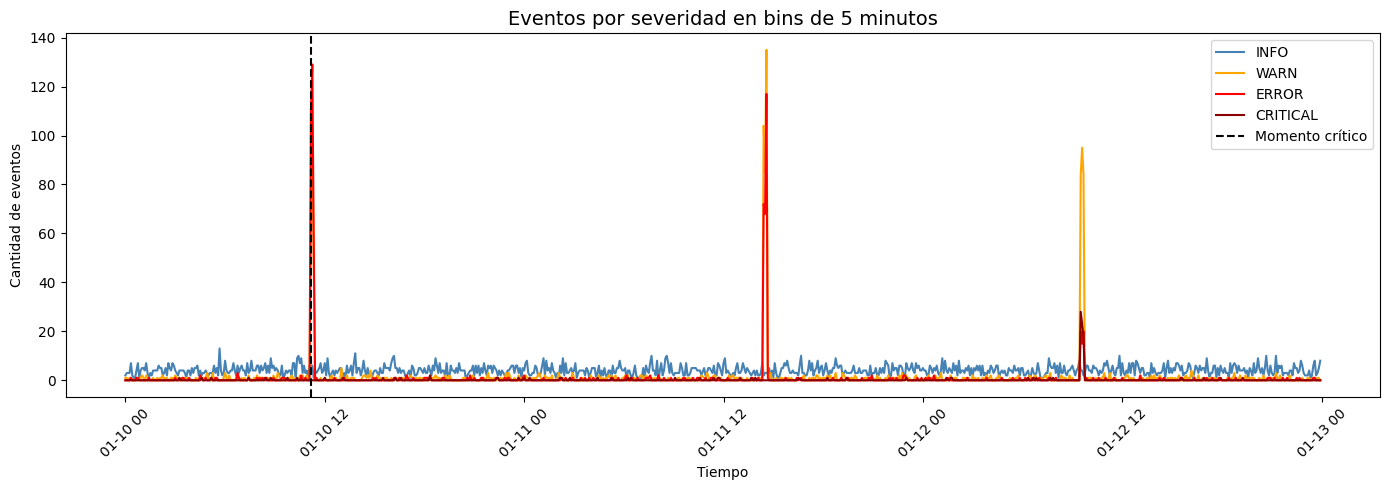

In [42]:
# Preparar datos
severidades = ['INFO', 'WARN', 'ERROR', 'CRITICAL']
colores     = ['steelblue', 'orange', 'red', 'darkred']

pivot = (
    df.groupby(['window', 'severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=severidades, fill_value=0)
)

# Graficar
fig, ax = plt.subplots(figsize=(14, 5))

for sev, color in zip(severidades, colores):
    ax.plot(pivot.index, pivot[sev], label=sev, color=color, linewidth=1.5)

# Marcar momento crítico
ax.axvline(x=ventana_critica, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

ax.set_title('Eventos por severidad en bins de 5 minutos', fontsize=14)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Cantidad de eventos')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

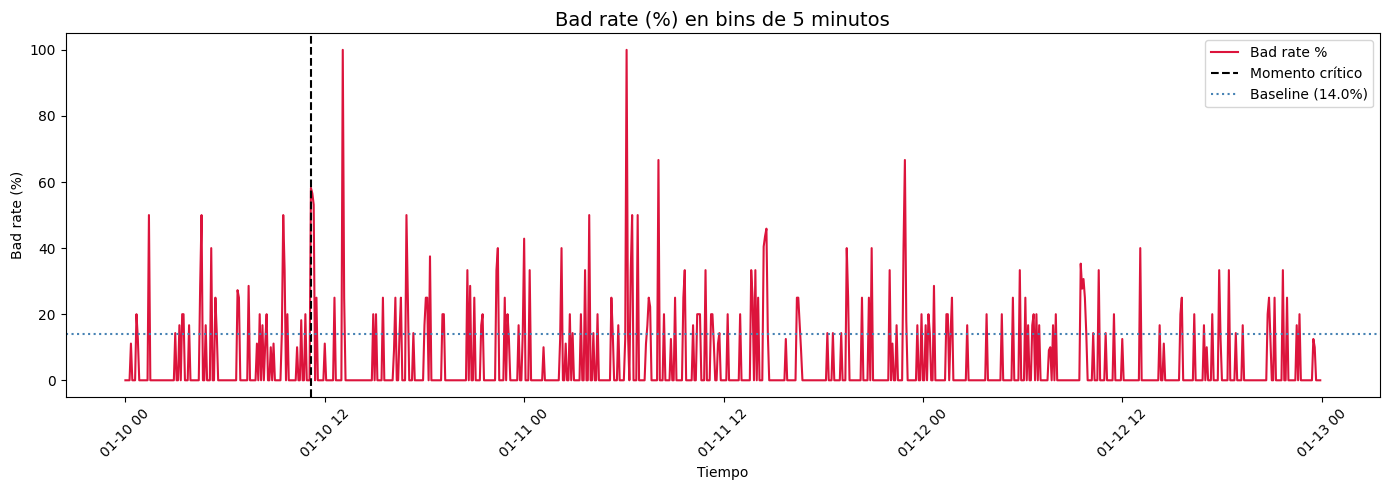

In [43]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(resumen['window'], resumen['bad_rate'] * 100,
        color='crimson', linewidth=1.5, label='Bad rate %')

# Marcar momento crítico
ax.axvline(x=ventana_critica, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

# Marcar línea de baseline
baseline_rate = round(df_baseline['is_bad'].mean() * 100, 2)
ax.axhline(y=baseline_rate, color='steelblue', linestyle=':', linewidth=1.5,
           label=f'Baseline ({baseline_rate}%)')

ax.set_title('Bad rate (%) en bins de 5 minutos', fontsize=14)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Bad rate (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()